# From one cortical column to fitting EEG spectra: the project's method in miniature

This notebook rebuilds every step of the MDD–TVB pipeline in a small form you can see and change.
It uses **one brain region** instead of 200, and **one EEG channel (Oz)** instead of 26, on your own TDBRAIN data.
Each section has a short explanation, a small piece of code and a plot.

| § | Here (toy version) | In the project |
|---|---|---|
| 1 | one Jansen–Rit cortical column | 200 columns wired by a connectome = The Virtual Brain (TVB) |
| 2 | the spectrum of one signal (Welch) | the 26 × 26 cross-spectrum of each recording |
| 3 | "bell or clock": is the rhythm noise-driven or self-sustained? | audit finding: M5.1's fits were clocks (progress_v2, slide 4) |
| 4 | the exact spectrum without simulating (linearisation) | M5.3's main change (slide 9) |
| 5 | the knobs (parameters) and what they do | global parameters, network gains, background terms |
| 6 | one real subject's spectrum, in two halves | fit on the first half, test on the second |
| 7 | how to score a guess: the likelihood | M5.4's complex-Wishart (Whittle) likelihood |
| 8 | priors and the best fit | M5.4's fit |
| 9 | how sure we are: the Laplace approximation | M5.4's posteriors |
| 10 | predicting the unseen half | the main score: "unseen deviance / population average" |
| 11 | recovery: can the knob values be trusted? | "24 / 24 parameters recovered" |
| 12 | two regions: delays, coherence, volume conduction | lagged vs zero-lag coherence, the lead field |
| 13 | the toy next to the real models for the same person | M5.3 and M5.4 predictions |
| 14 | where DCM fits in | the recipe M5.4 borrowed |

**How to use it:** run the cells from top to bottom (Shift + Enter). The whole notebook runs in about two minutes.
Exercises are at the end. Nothing here changes any project file.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize
from scipy.integrate import solve_ivp

ROOT = Path.cwd().parent if (Path.cwd().parent / "outputs").exists() else Path.cwd()   # the repository folder
plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 11, "legend.frameon": False})
DATA, MODEL, OTHER, GREY = "#17354D", "#DE7637", "#1B6AA3", "#9AA9B5"   # measured data, model, a second model, references

## 1. One cortical column: the Jansen–Rit model

A small patch of cortex (a "column", a few millimetres wide) is described by **three groups of neurons**:

- **pyramidal cells**: the main output of the column. EEG mostly measures their membrane potential, called **v** here;
- **excitatory interneurons**: they receive the pyramidal cells' output and excite them back;
- **inhibitory interneurons**: they receive the same output and inhibit them back.

Every connection works in two steps:

1. **synaptic filter.** Incoming spikes produce a smooth bump of membrane potential that rises and decays within about
   10 ms (excitatory synapses, rate `a = 100 /s`) or 20 ms (inhibitory synapses, `b = 50 /s`);
2. **sigmoid `S(v)`.** Membrane potential is turned back into a firing rate that saturates at 5 spikes/s.

The column also receives an **input from the rest of the brain, `p(t)`**: a steady part (the **drive `p`**) plus random fluctuations (**noise** of size σ).

Fast excitation and slower inhibition chase each other around the loop. The column therefore "rings" at about 10 Hz,
which is this model's **alpha rhythm**.

Each synaptic filter is a second-order differential equation, so the column has six equations
(`y0` is the pyramidal output, `y1` and `y2` its excitatory and inhibitory input potentials, `y3`–`y5` their rates of change):

$$\dot y_0 = y_3,\quad \dot y_3 = A a\,S(y_1-y_2) - 2a\,y_3 - a^2 y_0$$
$$\dot y_1 = y_4,\quad \dot y_4 = A a\,\big[p(t) + C_2\,S(C_1 y_0)\big] - 2a\,y_4 - a^2 y_1$$
$$\dot y_2 = y_5,\quad \dot y_5 = B b\,C_4\,S(C_3 y_0) - 2b\,y_5 - b^2 y_2$$

The EEG-like output is **v = y1 − y2**: excitatory minus inhibitory input to the pyramidal cells.

*In the project:* `src/mdd_tvb/linear_spectral.py` and `jax_backend.py` use the same equations, in TVB's units
(milliseconds), with a second, faster copy of the column for beta. Here we keep the textbook form (Jansen & Rit 1995).

In [2]:
# --- Jansen–Rit constants (Jansen & Rit 1995) ---
A, B = 3.25, 22.0              # largest excitatory / inhibitory potential bump (mV)
a, b = 100.0, 50.0             # synaptic rates (1/s): bumps last ~10 ms (excitatory) and ~20 ms (inhibitory)
C = 135.0                      # number of connections inside the column
C1, C2, C3, C4 = C, 0.8 * C, 0.25 * C, 0.25 * C
e0, v0, r = 2.5, 6.0, 0.56     # sigmoid: maximum rate 2*e0 = 5 /s, threshold 6 mV, steepness


def S(v):
    # sigmoid: membrane potential (mV) -> firing rate (spikes/s)
    return 2 * e0 / (1 + np.exp(r * (v0 - v)))


def derivatives(x, p, k=1.0):
    # the six equations; x = (y0, y1, y2, y3, y4, y5).  k speeds the whole column up:
    # both synaptic rates are multiplied by k while each filter's total effect (A/a, B/b) stays the same.
    y0, y1, y2, y3, y4, y5 = x
    aa, bb, AA, BB = a * k, b * k, A * k, B * k
    return np.array([
        y3, y4, y5,
        AA * aa * S(y1 - y2) - 2 * aa * y3 - aa**2 * y0,               # pyramidal cells
        AA * aa * (p + C2 * S(C1 * y0)) - 2 * aa * y4 - aa**2 * y1,    # excitatory input to pyramidal cells
        BB * bb * C4 * S(C3 * y0) - 2 * bb * y5 - bb**2 * y2,          # inhibitory input to pyramidal cells
    ])


def simulate(p, sigma, seconds, k=1.0, dt=5e-4, fs=250, seed=0, x0=None, settle=1.0, return_state=False):
    # Heun's method (the stochastic integrator TVB uses): a trial step, then a step with the average of the two
    # slopes, plus a random kick in the input at every step.  (The simplest method, Euler, adds a little
    # artificial "anti-damping" to fast oscillations, enough to move the bell/clock edge of §3 in a simulation.)
    # The first `settle` seconds are discarded while the column settles from its starting values.
    # Returns the EEG-like signal v = y1 - y2, sampled at fs Hz.
    rng = np.random.default_rng(seed)
    x = np.array(x0 if x0 is not None else [0.1, 20.0, 15.0, 0, 0, 0], float)
    n, every, skip = int(round((settle + seconds) / dt)), int(round(1 / (fs * dt))), int(round(settle / dt))
    kicks = A * k * a * k * sigma * np.sqrt(dt) * rng.standard_normal(n)   # the noise enters together with p
    out = []
    for i in range(n):
        slope = derivatives(x, p, k)
        trial = x + dt * slope; trial[4] += kicks[i]
        x = x + 0.5 * dt * (slope + derivatives(trial, p, k)); x[4] += kicks[i]
        if i >= skip and (i - skip) % every == 0:
            out.append(x[1] - x[2])
    out = np.array(out)
    return (out, x) if return_state else out

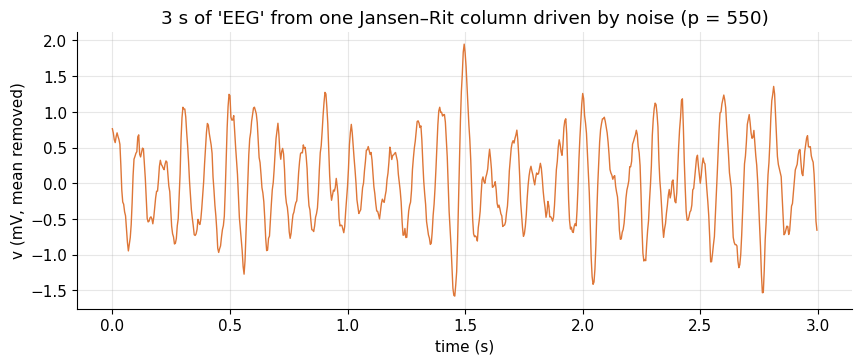

In [3]:
eeg = simulate(p=550, sigma=2.0, seconds=10)
t = np.arange(len(eeg)) / 250
plt.plot(t[:750], eeg[:750] - eeg.mean(), color=MODEL, lw=1)
plt.xlabel("time (s)"); plt.ylabel("v (mV, mean removed)")
plt.title("3 s of 'EEG' from one Jansen–Rit column driven by noise (p = 550)")
plt.show()

The output is an irregular rhythm near 10 Hz that waxes and wanes, which is roughly what resting EEG looks like.

### About the numbers in this plot

- **Millivolts, not microvolts.** `v` is the average membrane potential of the pyramidal cells *inside* the column.
  Scalp EEG is a few tens of microvolts because the **lead field** shrinks it: the electrode is centimetres away, behind
  the skull, and sees the summed currents of a whole patch, which partly cancel. The fit never compares the model's
  absolute size with the data. Only the spectrum's **shape** is fitted; the overall loudness is set aside (§5, §7).
- **The mean that was removed (about 9.7 mV) is the column's operating point.** A steady drive of 550 pulses/s keeps
  the pyramidal cells depolarised. At rest the drive and the two feedback loops balance (printed below).
  EEG cannot see this steady level: amplifiers and the cleaning's high-pass filter remove it, and the linearised model
  of §4 only describes fluctuations *around* it. The operating point still matters a great deal, though: it sets
  how steep the sigmoid is there, and that decides whether the column is a bell or a clock (§3).
- **How big is the noise?** The random input fluctuates by about 6 % of the drive, about half of what Jansen & Rit
  used in 1995. `v` then fluctuates with an SD of about 0.5 mV, a quarter of the sigmoid's width (1/r ≈ 1.8 mV).
  So the column stays nearly linear, which §4 checks directly; at σ = 10 that breaks down.
- **With σ = 0 you will see only a tiny wave of a few microvolts at the start.** That is the tail of the start-up
  transient, not a reference size. The simulation starts about 8 mV away from rest, and the first second is discarded
  while it dies away. Its size depends only on where the simulation started and how long it waited.

In [4]:
def resting_v(p):
    # the column's resting potential: where the drive and both feedback loops balance (the upper solution)
    g = lambda v: A / a * (p + C2 * S(C1 * A / a * S(v))) - B / b * C4 * S(C3 * A / a * S(v)) - v
    grid = np.linspace(-30, 90, 12001); gv = g(grid)
    j = np.flatnonzero(np.sign(gv[:-1]) != np.sign(gv[1:]))[-1]
    return brentq(g, grid[j], grid[j + 1])


v_rest = resting_v(550); y0_rest = A / a * S(v_rest)
print(f"operating point v* = {v_rest:.2f} mV   (the mean of the simulated signal: {eeg.mean():.2f} mV)")
print(f"  = drive {A / a * 550:.2f}  + excitatory feedback {A / a * C2 * S(C1 * y0_rest):.2f}"
      f"  - inhibitory feedback {B / b * C4 * S(C3 * y0_rest):.2f} mV")
print(f"pyramidal cells fire at {S(v_rest):.2f} of at most {2 * e0:.0f} spikes/s: close to saturation")
print(f"noise: input fluctuations SD ≈ {np.sqrt(2 * 2.0**2 * 125):.0f} pulses/s (0-125 Hz) vs mean drive 550;"
      f" Jansen & Rit 1995: SD ≈ {200 / np.sqrt(12):.0f}")
print(f"v fluctuates with SD {eeg.std():.2f} mV around v*")

operating point v* = 9.69 mV   (the mean of the simulated signal: 9.73 mV)
  = drive 17.88  + excitatory feedback 17.54  - inhibitory feedback 25.73 mV
pyramidal cells fire at 4.44 of at most 5 spikes/s: close to saturation
noise: input fluctuations SD ≈ 32 pulses/s (0-125 Hz) vs mean drive 550; Jansen & Rit 1995: SD ≈ 58
v fluctuates with SD 0.50 mV around v*


## 2. From a signal to a spectrum (Welch's method)

A **power spectrum** says how much of the signal's variance sits at each frequency.
To estimate it the project uses **Welch's method**:

1. cut the recording into **4-second windows** that overlap by half;
2. taper each window smoothly (a Hann window) and take its Fourier transform: the power at each frequency;
3. **average** the windows, then average the 0.25-Hz values into **1-Hz bins from 2 to 40 Hz**.

One window gives a very jagged estimate; averaging many windows smooths it.
How much information has been averaged is summarised by the **degrees of freedom ν**.
In the project ν ≈ 2.2 per 4-s window, and ν matters again in §7.

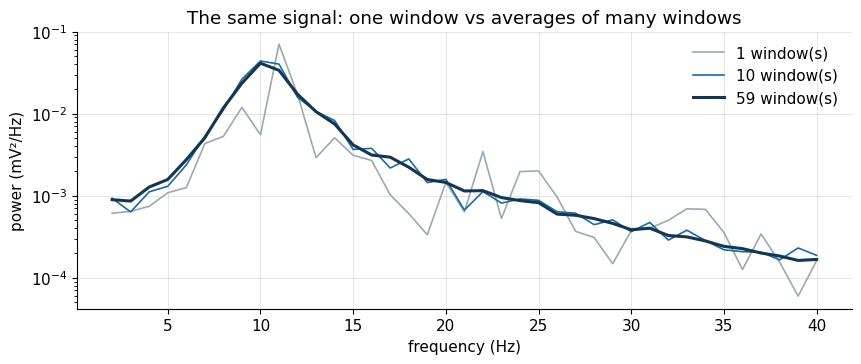

In [5]:
def spectrum(x, fs=250, window_s=4.0, fmin=2, fmax=40, max_windows=None):
    # project-style power spectrum: 4-s Hann windows, half overlap, averaged, then 1-Hz bins (2-40 Hz)
    n = int(window_s * fs); w = np.hanning(n)
    starts = list(range(0, len(x) - n + 1, n // 2))[:max_windows]
    P = np.mean([np.abs(np.fft.rfft((x[s:s + n] - x[s:s + n].mean()) * w)) ** 2 for s in starts], axis=0)
    P *= 2 / (fs * np.sum(w ** 2))                       # one-sided power spectral density
    fr = np.fft.rfftfreq(n, 1 / fs)
    centres = np.arange(fmin, fmax + 1.0)
    return centres, np.array([P[(fr >= c - 0.5) & (fr < c + 0.5)].mean() for c in centres]), len(starts)


eeg = simulate(p=550, sigma=2.0, seconds=120, seed=1)
for nw, color in ((1, GREY), (10, OTHER), (None, DATA)):
    f, P, used = spectrum(eeg, max_windows=nw)
    plt.semilogy(f, P, color=color, lw=1.2 if nw else 2.2, label=f"{used} window(s)")
plt.xlabel("frequency (Hz)"); plt.ylabel("power (mV²/Hz)"); plt.legend()
plt.title("The same signal: one window vs averages of many windows")
plt.show()

With one window the spectrum is mostly noise. With all of them the alpha peak and the shape of the spectrum are clear.
The leftover wiggles are the **sampling scatter** that the likelihood in §7 accounts for.

## 3. Bell or clock?

A model can produce a 10 Hz rhythm in two very different ways:

- **a bell (stable, noise-driven).** Left alone, the column would sit still at a resting point.
  Random input keeps "striking" it and it rings at its own pitch: irregular, waxing and waning. This is how resting EEG is thought to arise.
- **a clock (limit cycle).** The column oscillates by itself even with no input at all, giving a regular, machine-like wave.

**The test:** switch the noise off and see whether the rhythm dies away (bell) or keeps going (clock).

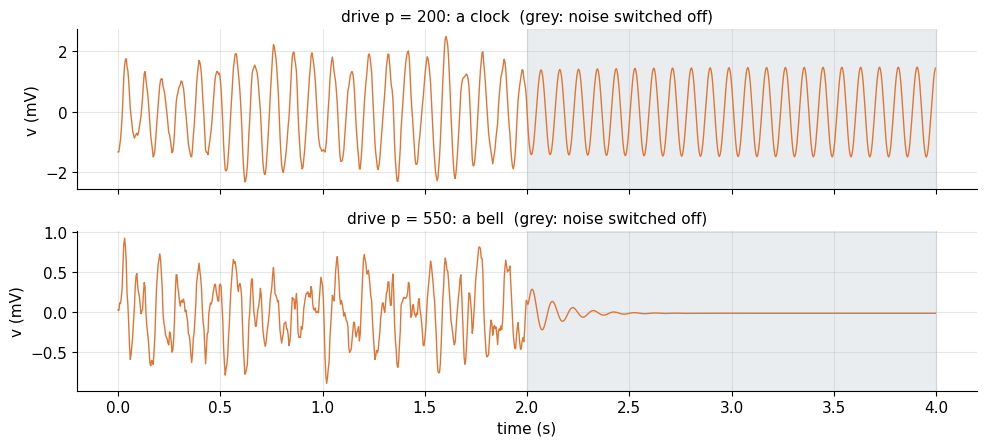

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
for ax, p, name in ((axes[0], 200.0, "drive p = 200: a clock"), (axes[1], 550.0, "drive p = 550: a bell")):
    on, state = simulate(p, sigma=2.0, seconds=2.0, return_state=True, seed=3)
    off = simulate(p, sigma=0.0, seconds=2.0, x0=state, settle=0.0)   # same column, noise switched off
    x = np.r_[on, off]; t = np.arange(len(x)) / 250
    ax.plot(t, x - on.mean(), color=MODEL, lw=1)
    ax.axvspan(2, 4, color=GREY, alpha=0.2)
    ax.set_title(name + "  (grey: noise switched off)", fontsize=11); ax.set_ylabel("v (mV)")
axes[1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

Whether the column is a bell or a clock can be computed without simulating. At the resting point we take the
**Jacobian**, the matrix that says how a small push in each variable changes every other variable.
Its **eigenvalues** describe how a small kick evolves:

- the real part is the decay rate: **negative means the kick dies away (bell)**, positive means it grows (clock);
- the imaginary part gives the ringing frequency.

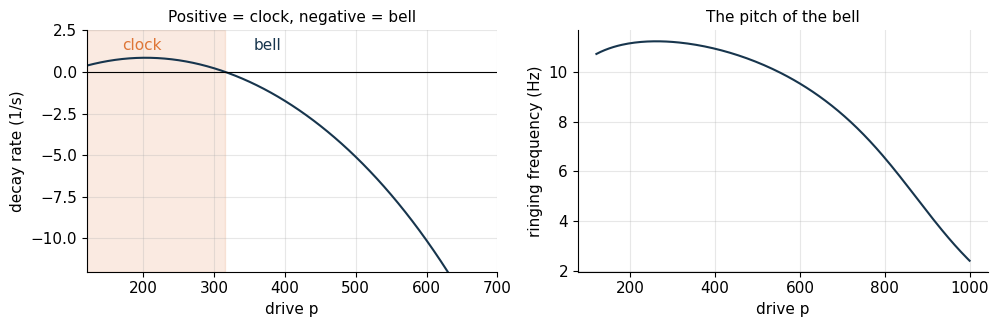

The column is a clock for drives between about 115 and 316, and a bell above 316.


In [7]:
def resting_points(p):
    # all resting points of the column for drive p (lowest to highest potential).
    # At rest every derivative is zero and everything follows from v = y1 - y2, so we search v on a grid.
    def g(v):
        y0 = A / a * S(v)
        return A / a * (p + C2 * S(C1 * y0)) - B / b * C4 * S(C3 * y0) - v
    grid = np.linspace(-30, 90, 12001); gv = g(grid)
    points = []
    for i in np.flatnonzero(np.sign(gv[:-1]) != np.sign(gv[1:])):
        v = brentq(g, grid[i], grid[i + 1])
        y0 = A / a * S(v); y2 = B / b * C4 * S(C3 * y0)
        points.append(np.array([y0, v + y2, y2, 0, 0, 0]))
    return points


def dS(v):
    # slope of the sigmoid
    s = S(v)
    return r * s * (1 - s / (2 * e0))


def jacobian(x, k=1.0):
    # the straight-line (linear) version of the six equations around the resting point x: a 6 x 6 matrix
    y0, y1, y2 = x[:3]
    aa, bb, AA, BB = a * k, b * k, A * k, B * k
    J = np.zeros((6, 6))
    J[0, 3] = J[1, 4] = J[2, 5] = 1
    J[3, 0], J[3, 3], J[3, 1], J[3, 2] = -aa**2, -2 * aa, AA * aa * dS(y1 - y2), -AA * aa * dS(y1 - y2)
    J[4, 0], J[4, 1], J[4, 4] = AA * aa * C2 * C1 * dS(C1 * y0), -aa**2, -2 * aa
    J[5, 0], J[5, 2], J[5, 5] = BB * bb * C4 * C3 * dS(C3 * y0), -bb**2, -2 * bb
    return J


def ringing(p, k=1.0):
    # leading eigenvalue at the upper resting point: decay rate (1/s; negative = bell) and frequency (Hz)
    ev = np.linalg.eigvals(jacobian(resting_points(p)[-1], k))
    lead = ev[np.argmax(ev.real)]
    return lead.real, abs(lead.imag) / (2 * np.pi)


P_EDGE = brentq(lambda p: ringing(p)[0], 250, 400)     # the drive where the clock turns into a bell
drives = np.arange(120, 1001, 5)
rates, freqs = np.array([ringing(p) for p in drives]).T
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(drives, rates, color=DATA); ax[0].axhline(0, color="k", lw=0.8)
ax[0].axvspan(drives[0], P_EDGE, color=MODEL, alpha=0.15)
ax[0].text(170, 1.3, "clock", color=MODEL); ax[0].text(P_EDGE + 40, 1.3, "bell", color=DATA)
ax[0].set_xlim(120, 700); ax[0].set_ylim(-12, 2.5)
ax[0].set_xlabel("drive p"); ax[0].set_ylabel("decay rate (1/s)"); ax[0].set_title("Positive = clock, negative = bell", fontsize=11)
ax[1].plot(drives, freqs, color=DATA); ax[1].set_xlabel("drive p"); ax[1].set_ylabel("ringing frequency (Hz)")
ax[1].set_title("The pitch of the bell", fontsize=11)
plt.tight_layout(); plt.show()
print(f"The column is a clock for drives between about 115 and {P_EDGE:.0f}, and a bell above {P_EDGE:.0f}.")

### Why high drive makes a bell, and how the clock is born: a Hopf bifurcation

**The mechanism.** A stronger drive pushes the pyramidal cells towards saturation (§1). There the sigmoid is flatter,
so each feedback loop passes on less of every fluctuation. Weaker feedback means more damping: a bell.
Lower the drive and the slope steepens, the feedback strengthens, and the damping shrinks. At p ≈ 316 it reaches zero.

**The edge is a Hopf bifurcation.** That is the name for the point where a pair of eigenvalues crosses from decaying to
growing (the decay rate in the chart above passes through zero, at about 11 Hz). Here it is a **supercritical** Hopf:

- just below the edge, the self-sustained rhythm is born with **zero size** and grows gradually, roughly as √(edge − p);
- just above the edge, no clock exists alongside the bell. A big kick at p = 320 simply dies away.

The plots below check both with an accurate (non-random) integrator. The value 315.7 is the one reported in the published
bifurcation analysis of this model (Grimbert & Faugeras, 2006).

Two consequences:

- **close to the edge the bell rings for a long time after each kick** ("critical slowing down"), which makes the spectral
  peak tall and narrow. When a person's alpha peak is very sharp, a fit pushes the drive towards the edge;
- **Jansen & Rit's own 1995 simulations used inputs between 120 and 320,** mostly inside the clock range. Their alpha was a
  noisy clock, which helps explain how M5.1 ended up there.

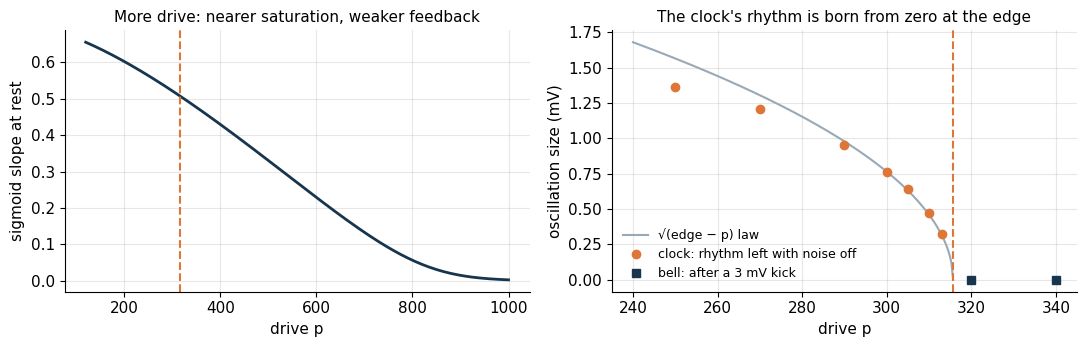

edge (Hopf bifurcation) at p = 315.70; after a 3 mV kick at p = 320 / 340 the oscillation is 0.0002 / 0.0000 mV


In [8]:
def clock_amplitude(p, kick=0.05, seconds=120.0):
    # size of the oscillation left after `seconds` with the noise off (accurate integrator, no randomness)
    x0 = resting_points(p)[-1] + np.array([0, kick, 0, 0, 0, 0])
    sol = solve_ivp(lambda t, x: derivatives(x, p), (0, seconds), x0, method="DOP853", rtol=1e-8, atol=1e-10,
                    t_eval=np.linspace(seconds - 2, seconds, 501))
    v = sol.y[1] - sol.y[2]
    return (v.max() - v.min()) / 2


below = np.array([250, 270, 290, 300, 305, 310, 313])
amp_below = np.array([clock_amplitude(p) for p in below])
above = {p: clock_amplitude(p, kick=3.0) for p in (320, 340)}          # big kicks just above the edge
c = np.median(amp_below / np.sqrt(P_EDGE - below))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
drive_grid = np.arange(120, 1001, 5)
slopes = [dS(resting_points(p)[-1][1] - resting_points(p)[-1][2]) for p in drive_grid]
ax[0].plot(drive_grid, slopes, color=DATA, lw=2)
ax[0].axvline(P_EDGE, color=MODEL, ls="--"); ax[0].set_xlabel("drive p"); ax[0].set_ylabel("sigmoid slope at rest")
ax[0].set_title("More drive: nearer saturation, weaker feedback", fontsize=11)
fine_p = np.linspace(240, P_EDGE, 200)
ax[1].plot(fine_p, c * np.sqrt(P_EDGE - fine_p), color=GREY, lw=1.5, label="√(edge − p) law")
ax[1].plot(below, amp_below, "o", color=MODEL, label="clock: rhythm left with noise off")
ax[1].plot(list(above), list(above.values()), "s", color=DATA, label="bell: after a 3 mV kick")
ax[1].axvline(P_EDGE, color=MODEL, ls="--"); ax[1].set_xlabel("drive p"); ax[1].set_ylabel("oscillation size (mV)")
ax[1].set_title("The clock's rhythm is born from zero at the edge", fontsize=11); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"edge (Hopf bifurcation) at p = {P_EDGE:.2f}; after a 3 mV kick at p = 320 / 340 the oscillation is "
      f"{above[320]:.4f} / {above[340]:.4f} mV")

**In the project:** the audit found that M5.1's best-fitting states were clocks in 318 of 327 subjects
(progress_v2, slide 4). The model produced its own rhythm, and much of the rest had to be explained by artificial
sensor noise. From M5.3 on, every fitted state is certified to be a bell.

## 4. The exact spectrum, without simulating

In the bell regime the noise only nudges the column a little away from its resting point.
For small nudges the curved sigmoid looks like a straight line (its slope at the resting point),
so the whole column behaves like a **linear filter**:

> what comes out at each frequency = what goes in at that frequency × **H(f)**

**H(f)** is the column's **transfer function**, its complex gain at each frequency. It follows directly from the Jacobian:

$$H(f) = c\,\big(i\,2\pi f\,I - J\big)^{-1} g$$

Here `g` says where the noise enters and `c` says what the EEG sees (v = y1 − y2).
The input noise has the same power at every frequency (white noise), so the output spectrum is

$$S(f) = 2\sigma^2\,|H(f)|^2$$

This is exact (for small noise), needs no random numbers, is thousands of times faster than simulating, and can be
differentiated, so it can be fitted. **This is M5.3's main change** (slide 9), and it is also how DCM works.

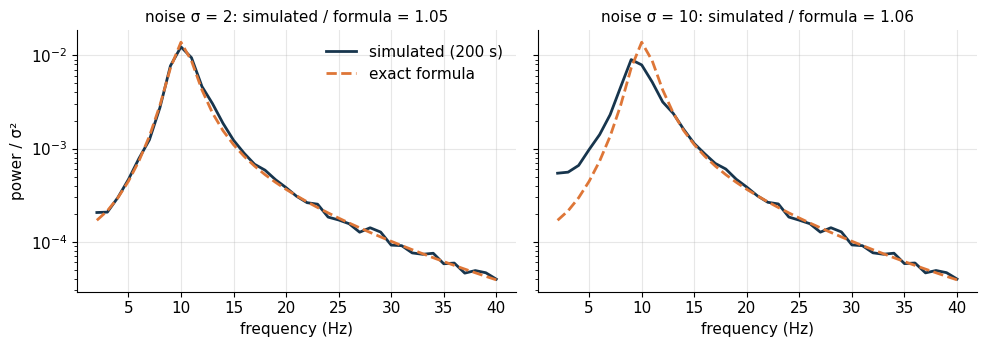

In [9]:
def transfer(f, p, k=1.0):
    # H(f): complex gain from the random input to the EEG signal v, at each frequency f
    J = jacobian(resting_points(p)[-1], k)
    g = np.zeros(6); g[4] = A * k * a * k        # where the noise enters
    c = np.zeros(6); c[1], c[2] = 1, -1           # what EEG sees: v = y1 - y2
    f = np.atleast_1d(np.asarray(f, float))
    M = 2j * np.pi * f[:, None, None] * np.eye(6) - J
    return np.linalg.solve(M, np.tile(g, (len(f), 1))[..., None])[..., 0] @ c


def exact_spectrum(f, p, sigma, k=1.0):
    return 2 * sigma**2 * np.abs(transfer(f, p, k)) ** 2


fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for axis, sigma in ((ax[0], 2.0), (ax[1], 10.0)):
    f, P, _ = spectrum(simulate(550, sigma, seconds=200, seed=2, x0=resting_points(550)[-1]))
    axis.semilogy(f, P / sigma**2, color=DATA, lw=2, label="simulated (200 s)")
    axis.semilogy(f, exact_spectrum(f, 550, sigma) / sigma**2, color=MODEL, lw=2, ls="--", label="exact formula")
    ratio = np.median(P / exact_spectrum(f, 550, sigma))
    axis.set_title(f"noise σ = {sigma:g}: simulated / formula = {ratio:.2f}", fontsize=11)
    axis.set_xlabel("frequency (Hz)")
ax[0].set_ylabel("power / σ²"); ax[0].legend(); plt.tight_layout(); plt.show()

- **Small noise (left):** the formula and the simulation agree. The remaining few-percent difference comes from random
  scatter and the small nonlinearity that the noise still feels.
- **Large noise (right):** the column is pushed far enough that the sigmoid's curvature matters.
  The real peak moves and broadens, and the linear formula no longer describes it.

**In the project:** this is why the analytic model is only used in a certified stable, small-fluctuation regime.
It was checked against the full stochastic simulator (agreement r = 0.9997, slide 9).

## 5. The knobs

Our toy model has two neural knobs and two for the background:

| knob | meaning | what it does to the spectrum |
|---|---|---|
| **k** | speed of the column (synaptic time scale) | moves the alpha peak in frequency (k = 1.1 → about 10 % faster) |
| **p** | drive; must stay above the edge (≈ 315) so the column is a bell | closer to the edge = less damping = a sharper, taller peak; far above it the pitch drops too |
| **w** | strength of a smooth background | real EEG has a broad "1/f" part not produced by one column |
| **χ** | steepness of that background | how fast the background falls with frequency |

The model spectrum is

$$S(f) = s\;\Big[\;\frac{|H(f;k,p)|^2}{\text{mean}} \;+\; w\,(f/10)^{-\chi}\Big]$$

The overall loudness `s` depends on skull, skin and amplifier rather than on the brain, so it is not treated as a knob.
For every shape we use its best value (§7). The project does the same ("profiled scale").

For the fit, each knob is written on a scale where any number is allowed: `log k`, `log(p − edge)`, `log w` and `χ`.
Writing the drive as `log(p − edge)` means **the fit can never pick a clock**. That is the toy version of the
project's stability certificate.

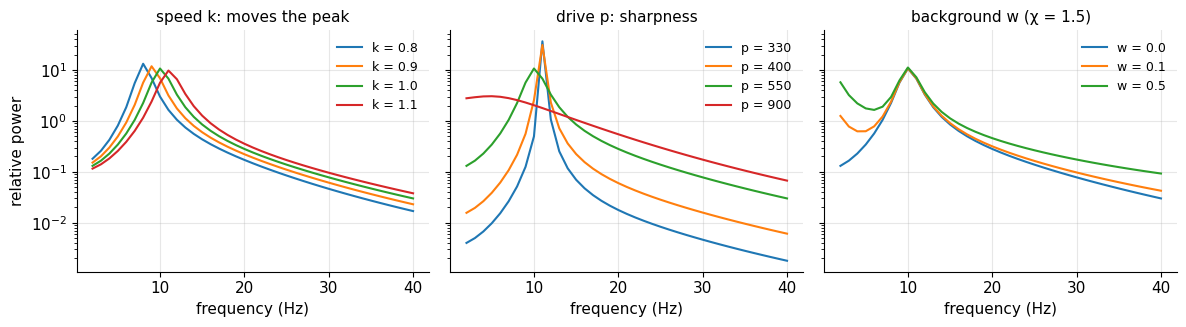

In [10]:
def unpack(theta):
    # fitting scale -> physical knobs
    lk, lp, lw, chi = theta
    return np.exp(lk), P_EDGE + np.exp(lp), np.exp(lw), chi


def model_parts(theta, f):
    k, p, w, chi = unpack(theta)
    h = np.abs(transfer(f, p, k)) ** 2
    return h / h.mean(), w * (f / 10.0) ** (-chi)          # (column, background)


def model_shape(theta, f):
    column, background = model_parts(theta, f)
    return column + background


f = np.arange(2, 41.0)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for k in (0.8, 0.9, 1.0, 1.1):
    ax[0].semilogy(f, model_shape([np.log(k), np.log(550 - P_EDGE), -20, 1], f), label=f"k = {k}")
for p in (330, 400, 550, 900):
    ax[1].semilogy(f, model_shape([0, np.log(p - P_EDGE), -20, 1], f), label=f"p = {p}")
for w in (0.0, 0.1, 0.5):
    ax[2].semilogy(f, model_shape([0, np.log(550 - P_EDGE), np.log(w + 1e-9), 1.5], f), label=f"w = {w}")
for axis, name in zip(ax, ("speed k: moves the peak", "drive p: sharpness", "background w (χ = 1.5)")):
    axis.set_title(name, fontsize=11); axis.set_xlabel("frequency (Hz)"); axis.legend(fontsize=9)
ax[0].set_ylabel("relative power"); plt.tight_layout(); plt.show()

## 6. Real data: one TDBRAIN subject

These are the project's cleaned spectra (`outputs/preproc_v2/dev_restEC/empirical`).
Every recording was **split in time into two halves**:

- **first half**: used for fitting;
- **second half**: kept hidden and used only to test the fit, like an exam the model has not seen.

We use the occipital channel **Oz**, where alpha is strongest.

sub-87959409 (Healthy): 24 windows in the first half -> ν = 52.8


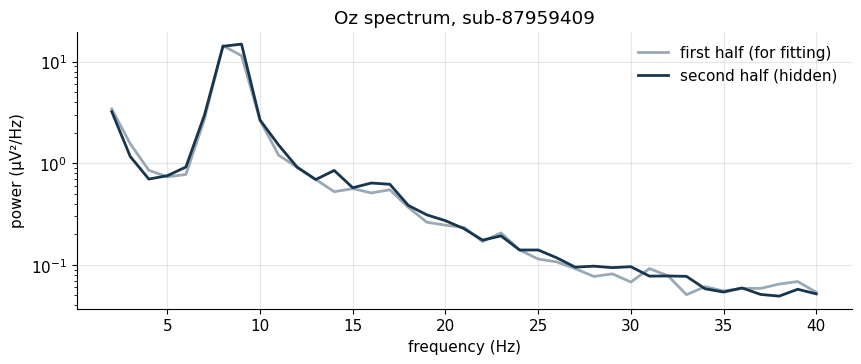

In [11]:
E = ROOT / "outputs/preproc_v2/dev_restEC/empirical"
first, second = np.load(E / "cross_spectra_fit.npz"), np.load(E / "cross_spectra_validation.npz")
ids = list(first["subject_ids"]); assert ids == list(second["subject_ids"])
freq = first["frequency_hz"]
oz = list(first["channel_names"]).index("Oz")
P_first = first["csd"][:, :, oz, oz].real * 1e12      # power spectral density in µV²/Hz
P_second = second["csd"][:, :, oz, oz].real * 1e12
NU_PER_WINDOW = 2.2                                    # degrees of freedom per 4-s window (calibrated in the project)
nu_first = NU_PER_WINDOW * first["epoch_counts"]
nu_second = NU_PER_WINDOW * second["epoch_counts"]
keep = set((ROOT / "configs/m54_lists/dev_restEC_v2.txt").read_text().split())   # the 252 subjects that passed QC
usable = [j for j, s in enumerate(ids) if s in keep]

SUBJECT = "sub-87959409"
i = ids.index(SUBJECT)
print(f"{SUBJECT} ({first['groups'][i]}): {first['epoch_counts'][i]} windows in the first half -> ν = {nu_first[i]:.1f}")
plt.semilogy(freq, P_first[i], color=GREY, lw=2, label="first half (for fitting)")
plt.semilogy(freq, P_second[i], color=DATA, lw=2, label="second half (hidden)")
plt.xlabel("frequency (Hz)"); plt.ylabel("power (µV²/Hz)"); plt.legend(); plt.title(f"Oz spectrum, {SUBJECT}")
plt.show()

The two halves agree closely but not exactly. Some of the difference is sampling scatter; some is real change in the
person's state over the recording. No model can be expected to predict the second half better than the first half does,
which is why the first half gives the **ceiling** in §10.

## 7. How to score a guess: the likelihood

Even a perfect model would not match the measured spectrum exactly, because each measurement averages only a finite
number of windows (§2). Statistics says exactly how a measured value **P** scatters around the true value **S**:
at each frequency, `P / S` follows a **Gamma distribution** with ν degrees of freedom, which is narrow when ν is large.

So for any guessed spectrum we can compute how probable the measured one is. Taking minus the logarithm and adding up the frequencies gives the **Whittle likelihood**:

$$-\log p(P \mid S) \;=\; \nu \sum_f \Big[\log S(f) + \frac{P(f)}{S(f)}\Big] + \text{const}$$

A smaller value means a better guess. Two properties matter:

- it compares **ratios**, so a 20 % error counts the same at 2 Hz and at 40 Hz, even though power differs a thousandfold;
- **more data (bigger ν) makes it stricter**.

**In the project:** M5.4 uses the multichannel version, `ν Σ [log det S + tr(S⁻¹ C)]`, for the whole 26 × 26
cross-spectrum (`src/mdd_tvb/whittle.py`).

The **deviance**, `D = 2ν Σ [P/S − log(P/S) − 1]`, is the same quantity shifted so that a perfect guess scores 0. It is used in §10.

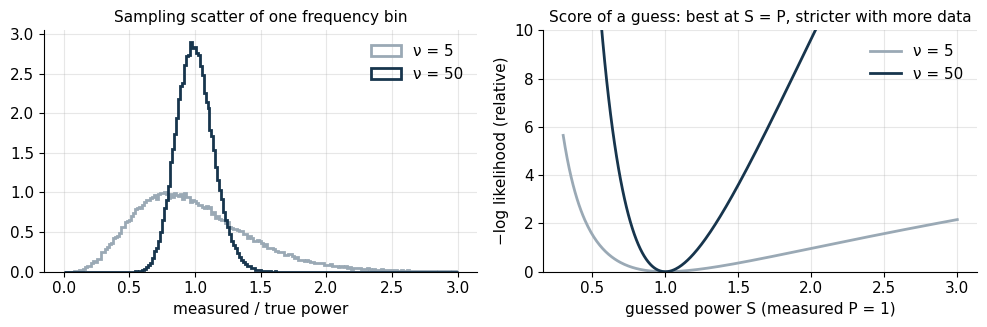

In [12]:
rng = np.random.default_rng(1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for nu, color in ((5, GREY), (50, DATA)):
    ax[0].hist(rng.gamma(nu, 1 / nu, 100_000), bins=200, range=(0, 3), density=True, histtype="step", lw=2,
               color=color, label=f"ν = {nu}")
    S_guess = np.linspace(0.3, 3, 400)
    nll = nu * (np.log(S_guess) + 1.0 / S_guess)            # measured P = 1 at this frequency
    ax[1].plot(S_guess, nll - nll.min(), color=color, lw=2, label=f"ν = {nu}")
ax[0].set_xlabel("measured / true power"); ax[0].set_title("Sampling scatter of one frequency bin", fontsize=11); ax[0].legend()
ax[1].set_xlabel("guessed power S (measured P = 1)"); ax[1].set_ylabel("−log likelihood (relative)")
ax[1].set_ylim(0, 10); ax[1].set_title("Score of a guess: best at S = P, stricter with more data", fontsize=11); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Priors and the best fit

Before seeing any data we already know roughly where the knobs should be: an alpha peak between about 7 and 13 Hz means
`k` near 1, the drive above the edge, and so on. This is written as a **prior**: a Gaussian for each knob, on the fitting
scale, with a mean and a width.

The **posterior** combines the prior with the data, `posterior ∝ likelihood × prior`. In minus-log form:

$$-\log \text{posterior}(\theta) \;=\; \underbrace{\nu \sum_f \Big[\log S_\theta(f) + \tfrac{P(f)}{S_\theta(f)}\Big]}_{\text{data}} \;+\; \underbrace{\tfrac12 \sum_j \Big(\tfrac{\theta_j - m_j}{s_j}\Big)^2}_{\text{prior}}$$

The **best fit** (MAP, maximum a posteriori) is the knob setting that makes this smallest.
A standard downhill optimiser (L-BFGS-B) finds it in a fraction of a second.

best fit: k = 0.805, p = 485 (edge 316), w = 0.288, χ = 1.39  -> model alpha peak at 8.45 Hz


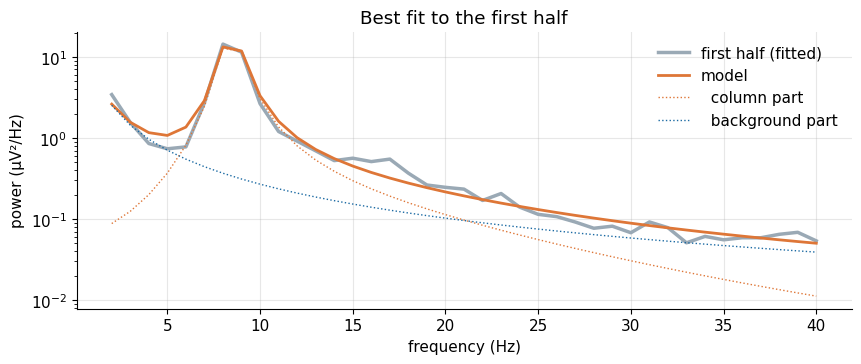

In [13]:
PRIOR_MEAN = np.array([0.0, np.log(200.0), np.log(0.5), 1.5])   # k ≈ 1, p ≈ edge + 200, w ≈ 0.5, χ ≈ 1.5
PRIOR_SD = np.array([0.2, 1.0, 1.5, 1.0])
BOUNDS = [(-0.7, 0.7), (np.log(2), np.log(1000)), (-8, 3), (0, 4)]
NAMES = ["log k", "log(p − edge)", "log w", "χ"]


def neg_log_post(theta, P, nu, prior_mean=PRIOR_MEAN, prior_sd=PRIOR_SD):
    g = model_shape(theta, freq)
    s = np.mean(P / g)                                           # best overall loudness for this shape
    data = nu * np.sum(np.log(s * g) + P / (s * g))
    prior = 0.5 * np.sum(((np.asarray(theta) - prior_mean) / prior_sd) ** 2)
    return data + prior


def fit(P, nu, prior_mean=PRIOR_MEAN, prior_sd=PRIOR_SD):
    return minimize(neg_log_post, prior_mean, args=(P, nu, prior_mean, prior_sd), method="L-BFGS-B", bounds=BOUNDS)


def peak_frequency(theta):
    fine = np.arange(5, 15, 0.05)
    return fine[np.argmax(model_parts(theta, fine)[0])]


best = fit(P_first[i], nu_first[i])
k_hat, p_hat, w_hat, chi_hat = unpack(best.x)
print(f"best fit: k = {k_hat:.3f}, p = {p_hat:.0f} (edge {P_EDGE:.0f}), w = {w_hat:.3f}, χ = {chi_hat:.2f}"
      f"  -> model alpha peak at {peak_frequency(best.x):.2f} Hz")

column, background = model_parts(best.x, freq)
s_hat = np.mean(P_first[i] / (column + background))
plt.semilogy(freq, P_first[i], color=GREY, lw=2.5, label="first half (fitted)")
plt.semilogy(freq, s_hat * (column + background), color=MODEL, lw=2, label="model")
plt.semilogy(freq, s_hat * column, color=MODEL, lw=1, ls=":", label="  column part")
plt.semilogy(freq, s_hat * background, color=OTHER, lw=1, ls=":", label="  background part")
plt.xlabel("frequency (Hz)"); plt.ylabel("power (µV²/Hz)"); plt.legend(); plt.title("Best fit to the first half")
plt.show()

To see how the data pin down the knobs, scan them. On the left, `k` is fixed at each value and the other three knobs are
re-optimised (a **profile**). On the right, `k` and `p` are scanned together, with `w` and `χ` held at their best values.

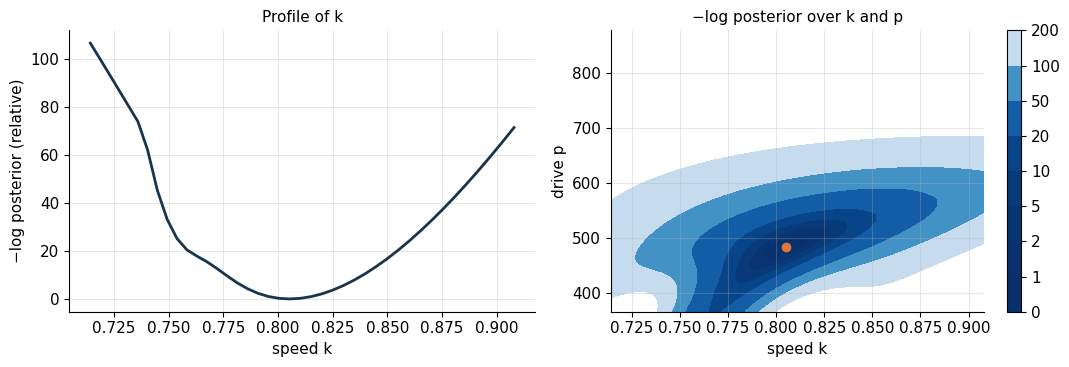

In [14]:
lk_grid = best.x[0] + np.linspace(-0.12, 0.12, 41)


def profile(theta_best, P, nu, grid):
    # fix k at each grid value and re-optimise the other knobs, walking outwards from the best fit
    values = np.empty(len(grid))
    centre = int(np.argmin(np.abs(grid - theta_best[0])))
    for steps in (range(centre, len(grid)), range(centre, -1, -1)):
        start = theta_best[1:]
        for j in steps:   # two starting points (the neighbour's solution and the best fit); keep the better
            tries = [minimize(lambda rest: neg_log_post(np.r_[grid[j], rest], P, nu), s0, method="L-BFGS-B",
                              bounds=BOUNDS[1:]) for s0 in (start, theta_best[1:])]
            res = min(tries, key=lambda t: t.fun)
            values[j], start = res.fun, res.x
    return values


prof = profile(best.x, P_first[i], nu_first[i], lk_grid)
lp_grid = best.x[1] + np.linspace(-1.2, 1.2, 41)
surface = np.array([[neg_log_post([lk, lp, best.x[2], best.x[3]], P_first[i], nu_first[i]) for lk in lk_grid]
                    for lp in lp_grid])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(np.exp(lk_grid), prof - prof.min(), color=DATA, lw=2)
ax[0].set_xlabel("speed k"); ax[0].set_ylabel("−log posterior (relative)"); ax[0].set_title("Profile of k", fontsize=11)
cs = ax[1].contourf(np.exp(lk_grid), P_EDGE + np.exp(lp_grid), surface - surface.min(), levels=[0, 1, 2, 5, 10, 20, 50, 100, 200],
                    cmap="Blues_r")
ax[1].plot(k_hat, p_hat, "o", color=MODEL)
ax[1].set_xlabel("speed k"); ax[1].set_ylabel("drive p"); ax[1].set_title("−log posterior over k and p", fontsize=11)
fig.colorbar(cs, ax=ax[1]); plt.tight_layout(); plt.show()

The valley on the right is **tilted**: both knobs can move the peak frequency, so a little more of one can partly make
up for a little less of the other. This is a **trade-off between parameters**. In the full model, trade-offs like this
are why some parameters had to be fixed or tied (slide 12: deep limbic gains, speed and the fast generator).

## 9. How sure are we? The Laplace approximation

Near its minimum, the −log posterior looks like a **bowl**. A steep, narrow bowl means the data pin the knob down
precisely; a flat bowl means they hardly constrain it.

The **Laplace approximation** replaces the bowl with a parabola fitted at the minimum. Then:

- the posterior is a Gaussian;
- its covariance is the inverse of the bowl's curvature matrix (the **Hessian**);
- the standard deviations give **error bars**, and the off-diagonal terms give the trade-offs as correlations.

**In the project:** M5.4 does exactly this, using the Fisher information of the likelihood as the curvature (`m54_fit.py`).

k = 0.805, 95% interval 0.792 – 0.819
posterior correlations (fitting scale):
[[1.   0.77 0.2  0.16]
 [0.77 1.   0.22 0.15]
 [0.2  0.22 1.   0.08]
 [0.16 0.15 0.08 1.  ]]


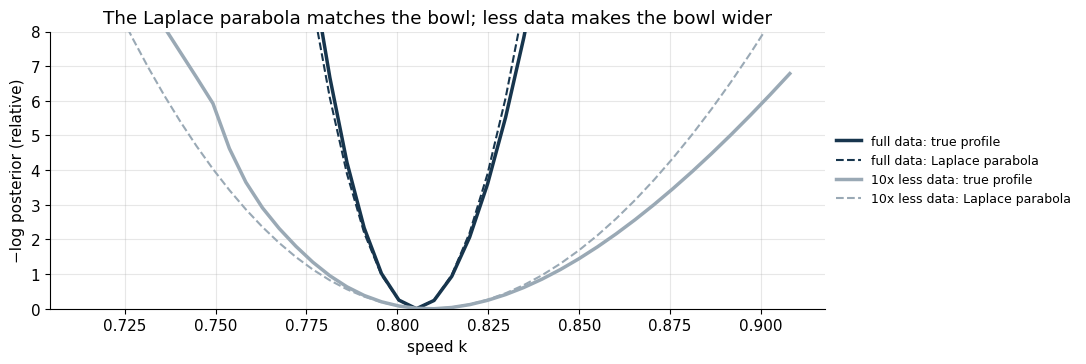

In [15]:
def hessian(fun, x, h=1e-3):
    # curvature matrix by finite differences
    n = len(x); H = np.zeros((n, n)); I = np.eye(n) * h
    for p_ in range(n):
        for q in range(p_, n):
            H[p_, q] = H[q, p_] = (fun(x + I[p_] + I[q]) - fun(x + I[p_] - I[q]) - fun(x - I[p_] + I[q])
                                   + fun(x - I[p_] - I[q])) / (4 * h * h)
    return H


def laplace(theta_best, P, nu):
    cov = np.linalg.inv(hessian(lambda t: neg_log_post(t, P, nu), theta_best))
    return cov, np.sqrt(np.diag(cov))


cov, sd = laplace(best.x, P_first[i], nu_first[i])
lo, hi = np.exp(best.x[0] - 1.96 * sd[0]), np.exp(best.x[0] + 1.96 * sd[0])
print(f"k = {k_hat:.3f}, 95% interval {lo:.3f} – {hi:.3f}")
print("posterior correlations (fitting scale):")
print(np.round(cov / np.outer(sd, sd), 2))

# the same subject with 10x less data (as if the recording were 10x shorter)
best_short = fit(P_first[i], nu_first[i] / 10)
prof_short = profile(best_short.x, P_first[i], nu_first[i] / 10, lk_grid)
_, sd_short = laplace(best_short.x, P_first[i], nu_first[i] / 10)
for x0, pr, s_, color, name in ((best.x[0], prof, sd[0], DATA, "full data"),
                                (best_short.x[0], prof_short, sd_short[0], GREY, "10x less data")):
    plt.plot(np.exp(lk_grid), pr - pr.min(), color=color, lw=2.5, label=f"{name}: true profile")
    plt.plot(np.exp(lk_grid), 0.5 * ((lk_grid - x0) / s_) ** 2, color=color, lw=1.5, ls="--", label=f"{name}: Laplace parabola")
plt.ylim(0, 8); plt.xlabel("speed k"); plt.ylabel("−log posterior (relative)")
plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.title("The Laplace parabola matches the bowl; less data makes the bowl wider"); plt.show()

- The dashed parabolas follow the true profiles closely near the minimum, so the Laplace error bars are reasonable here.
  Farther out the true bowl is lopsided (steeper towards slow speeds). There the Gaussian picture is only approximate,
  which is one reason the project checks its error bars by recovery (§11) and by comparing the two halves.
- With ten times less data the bowl is wider: the error bar on `k` grows by about √10 ≈ 3×.
  The prior also matters more, because it now counts relatively ten times as much.
- The correlation matrix shows the trade-off from §8 as a number (the `log k` / `log(p − edge)` entry).

## 10. Does the fit predict new data?

A good fit to the first half could simply mean the model is flexible. The real test is the **hidden second half**.
Three predictions for it are compared:

1. **the model**, fitted to the first half;
2. **the population average**: the mean spectral shape of all *other* subjects' first halves. It needs no fitting and is the baseline to beat;
3. **the ceiling**: the subject's own first half, the best any model of this person could hope for.

Each is scored with the deviance (§7). The project's main number is the ratio **model / population average**:
below 1 means the individual fit predicts this person better than the average does.

sub-87959409: model / average = 0.17, ceiling / average = 0.09


All 252 subjects: median model / average = 0.47, median ceiling / average = 0.19, model beats the average in 86% of subjects


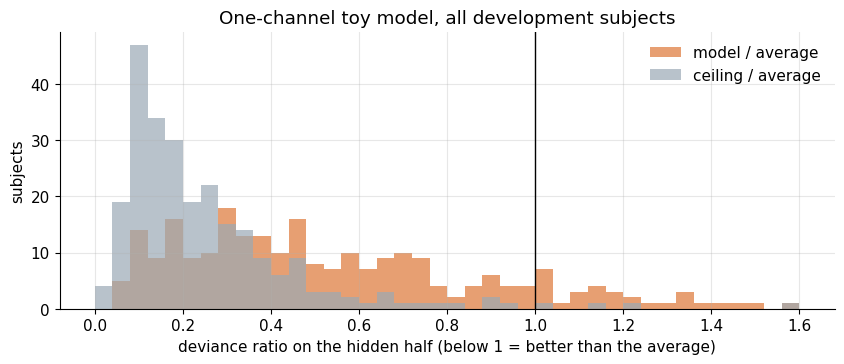

In [16]:
def deviance(P, shape, nu):
    q = P / (np.mean(P / shape) * shape)                 # best loudness, then compare shapes
    return 2 * nu * np.sum(q - np.log(q) - 1)


shapes = P_first / P_first.mean(axis=1, keepdims=True)   # each subject's spectral shape


def scores(j):
    theta = fit(P_first[j], nu_first[j]).x
    population = np.mean([shapes[m] for m in usable if m != j], axis=0)
    d = {name: deviance(P_second[j], s_, nu_second[j]) for name, s_ in
         (("model", model_shape(theta, freq)), ("average", population), ("ceiling", P_first[j]))}
    return d["model"] / d["average"], d["ceiling"] / d["average"], theta


m_ratio, c_ratio, _ = scores(i)
print(f"{SUBJECT}: model / average = {m_ratio:.2f}, ceiling / average = {c_ratio:.2f}")

all_scores = np.array([scores(j)[:2] for j in usable])
print(f"All {len(usable)} subjects: median model / average = {np.median(all_scores[:, 0]):.2f}, "
      f"median ceiling / average = {np.median(all_scores[:, 1]):.2f}, "
      f"model beats the average in {np.mean(all_scores[:, 0] < 1):.0%} of subjects")
plt.hist(all_scores[:, 0], bins=np.linspace(0, 1.6, 41), color=MODEL, alpha=0.7, label="model / average")
plt.hist(all_scores[:, 1], bins=np.linspace(0, 1.6, 41), color=GREY, alpha=0.7, label="ceiling / average")
plt.axvline(1, color="k", lw=1); plt.xlabel("deviance ratio on the hidden half (below 1 = better than the average)")
plt.ylabel("subjects"); plt.legend(); plt.title("One-channel toy model, all development subjects"); plt.show()

For a single channel, the toy model predicts most people's hidden half much better than the population average.
Do not compare these numbers directly with M5.4's **0.84**. That number is for **all 26 channels and every pair of
channels at once**, including how they co-vary in space, which is a far harder target (§12–13).

## 11. Can we trust the knob values? Recovery

A good fit does not prove that the knob values mean anything: different settings might produce almost the same spectrum.
The test is to make **fake data from the model with known knob values**, with the same amount of random scatter as the
real data, refit it, and compare:

- **recovery**: do the estimates track the true values? (correlation r; the project uses r ≥ 0.5 as "recovered");
- **calibration**: do the 95 % error bars contain the truth about 95 % of the time?

**In the project:** M5.3 recovered 19 of 27 parameters (slide 12). M5.4 recovered 24 of 24, with 90 % coverage.

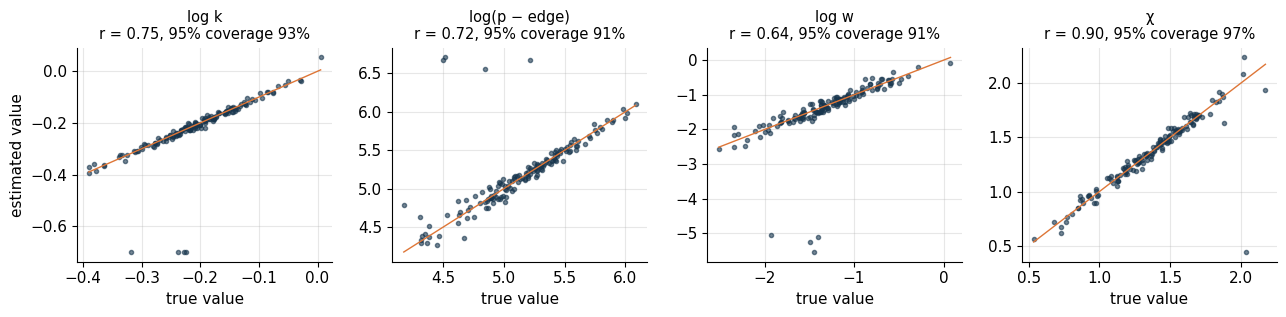

In [17]:
rng = np.random.default_rng(7)
nu = nu_first[i]
spread = np.array([0.08, 0.4, 0.5, 0.3])                # how much the true values vary between fake subjects
truth, estimate, errbar = [], [], []
for rep in range(150):
    theta_true = best.x + spread * rng.standard_normal(4)
    theta_true = np.clip(theta_true, [lo_ + 0.05 for lo_, _ in BOUNDS], [hi_ - 0.05 for _, hi_ in BOUNDS])
    P_fake = model_shape(theta_true, freq) * rng.gamma(nu, 1 / nu, len(freq))   # true spectrum × sampling scatter
    res = fit(P_fake, nu)
    try:
        _, s_ = laplace(res.x, P_fake, nu)
    except np.linalg.LinAlgError:
        s_ = np.full(4, np.nan)
    truth.append(theta_true); estimate.append(res.x); errbar.append(s_)
truth, estimate, errbar = map(np.array, (truth, estimate, errbar))

fig, ax = plt.subplots(1, 4, figsize=(13, 3.3))
for j in range(4):
    rj = np.corrcoef(truth[:, j], estimate[:, j])[0, 1]
    cover = np.nanmean(np.abs(estimate[:, j] - truth[:, j]) < 1.96 * errbar[:, j])
    ax[j].plot(truth[:, j], estimate[:, j], "o", ms=3, color=DATA, alpha=0.6)
    lim = [truth[:, j].min(), truth[:, j].max()]; ax[j].plot(lim, lim, color=MODEL, lw=1)
    ax[j].set_title(f"{NAMES[j]}\nr = {rj:.2f}, 95% coverage {cover:.0%}", fontsize=10.5)
    ax[j].set_xlabel("true value")
ax[0].set_ylabel("estimated value"); plt.tight_layout(); plt.show()

Most points hug the diagonal, so all four knobs are well identified by one channel's spectrum. Coverage near 95 % means
the error bars from §9 are honest. A knob with low r would be one to fix or tie in a bigger model, which is how the
project decided which parameters to keep free.

**The few points far off the diagonal** are fits that started from the prior mean and got stuck in a different
valley of the −log posterior. They also pull r down. This is why the project does not start each fit from one point:
it begins from the best of a **bank of 2,000 certified starting states** and only then refines.

## 12. Two regions: delays, coherence and volume conduction

Real EEG has many electrodes, and their signals are related. There are two very different reasons why:

1. **real interaction.** Region 1 sends activity to region 2 along a nerve fibre, which arrives after a **delay**
   (here 20 ms);
2. **volume conduction.** Currents spread through the head, so **each electrode picks up several regions at once**.
   This mixing is instantaneous (zero lag) and says nothing about brain interaction.

**Coherency** measures how related two signals are at each frequency. It is a complex number:

- its **size** says how strongly the signals are related;
- its **angle** says how far one lags the other.

Instantaneous mixing can only create a **real** coherency (zero lag); a delayed interaction creates an **imaginary**
part (a phase lag). This is why the project separates **zero-lag coherence** (mostly head physics) from
**lagged coherence** (genuine interaction).

We couple two identical columns in the linear regime, with region 1 driving region 2 after a delay τ:
`v1 = H·ξ1` and `v2 = H·(ξ2 + K·e^{−i2πfτ}·v1)`.
Then two electrodes each see a mixture of both regions, through a 2 × 2 **lead field** `L`.

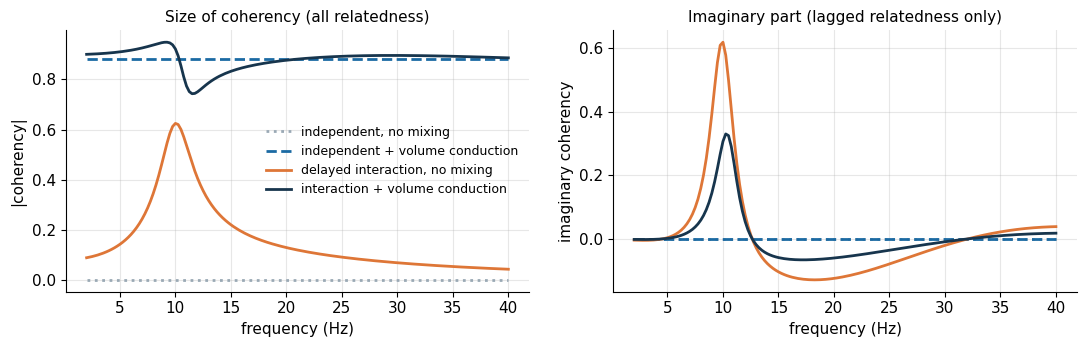

In [18]:
fine = np.arange(2, 40.01, 0.25)
p0 = 550.0
H0 = transfer(fine, p0)
K0 = 0.8 / np.abs(H0).max()                       # coupling strength (scaled to the column's gain)


def electrode_csd(K, tau, mix):
    # 2 x 2 cross-spectrum at each frequency: regions -> electrodes
    z = np.zeros_like(H0)
    M = np.stack([np.stack([H0, z], -1),
                  np.stack([H0 * K * np.exp(-2j * np.pi * fine * tau) * H0, H0], -1)], -2)   # (freq, region, noise source)
    regions = 2 * M @ M.conj().transpose(0, 2, 1)             # cross-spectrum of the two regions
    L = np.array([[1.0, mix], [mix, 1.0]])                    # lead field: what each electrode sees of each region
    return L @ regions @ L.T


def coherency(Sm):
    return Sm[:, 0, 1] / np.sqrt(Sm[:, 0, 0].real * Sm[:, 1, 1].real)


cases = [("independent, no mixing", 0, 0.0, GREY, ":"), ("independent + volume conduction", 0, 0.6, OTHER, "--"),
         ("delayed interaction, no mixing", K0, 0.0, MODEL, "-"), ("interaction + volume conduction", K0, 0.6, DATA, "-")]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for name, K, mix, color, ls in cases:
    c = coherency(electrode_csd(K, 0.020, mix))
    ax[0].plot(fine, np.abs(c), color=color, ls=ls, lw=2, label=name)
    ax[1].plot(fine, c.imag, color=color, ls=ls, lw=2)
ax[0].set_title("Size of coherency (all relatedness)", fontsize=11); ax[0].set_ylabel("|coherency|")
ax[1].set_title("Imaginary part (lagged relatedness only)", fontsize=11); ax[1].set_ylabel("imaginary coherency")
for axis in ax: axis.set_xlabel("frequency (Hz)")
ax[0].legend(fontsize=9); plt.tight_layout(); plt.show()

- **Volume conduction alone (blue, dashed)** makes the two electrodes look strongly related at every frequency, although
  the regions are independent. Its imaginary part is exactly zero.
- **A delayed interaction (orange)** gives a frequency-dependent relationship with a real **imaginary part**.
- **With mixing on top (dark)**, the size is inflated, but the imaginary part survives (scaled down). Mixing cannot
  create lagged coherence, only hide part of it.

**In the project:** the audit found that M5.1 could not produce the measured lagged alpha coherence (slide 5).
M5.3 added a shared, delayed alpha drive to restore it. The BEM head model is the realistic version of `L`.

## 13. From the toy to the project

The project's model is this notebook at full size:

$$S(f) \;=\; L \cdot M(f) \cdot \text{diag(noise)} \cdot M(f)^{H} \cdot L^{T}$$

| piece | toy (here) | project |
|---|---|---|
| `M(f)` | §4's transfer function (§12 for two regions) | 200 columns coupled by the connectome with conduction delays (`linear_spectral.py`, `linear_jax.py`) |
| `L` | the 2 × 2 mixing matrix of §12 | lead field from a head model: 26 electrodes × 200 regions (TVB formula or BEM) |
| noise | white input to the column | white input to each region, plus a shared delayed alpha drive (M5.3) |
| score | one-channel Whittle likelihood (§7) | 26-channel complex-Wishart likelihood (`whittle.py`) |
| fit | prior + best fit + Laplace (§8–9) | the same, with stability certification (`m54_fit.py`) |
| tests | hidden half (§10), recovery (§11) | `m54_evaluate.py`, synthetic recovery |

Below, the same person's hidden Oz spectrum is shown next to the toy fit and to the real models' predictions for this channel.

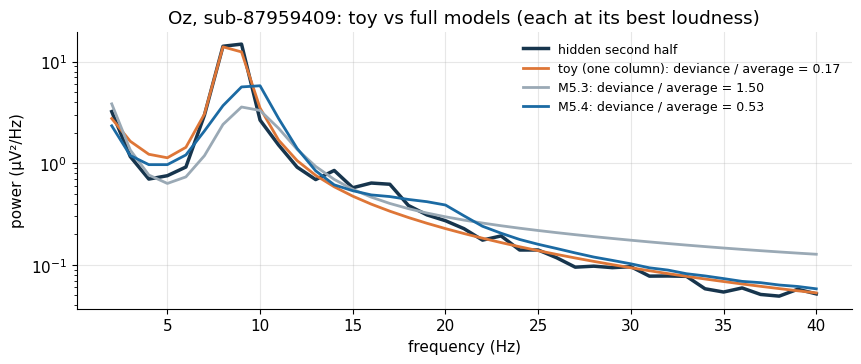

In [19]:
def prediction(path, sid):
    with np.load(ROOT / path) as z:
        j = list(z["subject_ids"].astype(str)).index(sid)
        return z["csd"][j][:, oz, oz].real * 1e12


preds = {"toy (one column)": (model_shape(best.x, freq), MODEL),
         "M5.3": (prediction("outputs/m54_kaggle_bem/results/m53v2_dev_refined/predictions.npz", SUBJECT), GREY),
         "M5.4": (prediction("outputs/m54b_kaggle_bem/results/dev_bem_m10pop/predictions.npz", SUBJECT), OTHER)}
population = np.mean([shapes[m] for m in usable if m != i], axis=0)
d_avg = deviance(P_second[i], population, nu_second[i])
plt.semilogy(freq, P_second[i], color=DATA, lw=2.5, label="hidden second half")
for name, (s_, color) in preds.items():
    ratio = deviance(P_second[i], s_, nu_second[i]) / d_avg
    plt.semilogy(freq, s_ * np.mean(P_second[i] / s_), color=color, lw=2, label=f"{name}: deviance / average = {ratio:.2f}")
plt.xlabel("frequency (Hz)"); plt.ylabel("power (µV²/Hz)"); plt.legend(fontsize=9)
plt.title(f"Oz, {SUBJECT}: toy vs full models (each at its best loudness)"); plt.show()

On one channel, the toy can look as good as the big models, or better: it spends all four knobs on a single spectrum.
The big models must explain **26 channels and how every pair co-varies**, with one brain shared by all electrodes.
That is much harder, and it is what makes their parameters (network gains, time scales) say something about the brain
rather than about one electrode.

The project's open problems are visible in the same terms:

- **beta.** Neither the toy nor M5.4 has an independent narrow beta rhythm, and posterior beta is partly a
  harmonic of non-sinusoidal alpha that no linear model can produce;
- **sharp alpha peaks.** A bell that rings very sharply sits close to the edge, so the drive is pushed toward it;
- **template.** In M5.4 much of the predicted power is the population template.

## 14. Where DCM fits in

**Dynamic Causal Modelling (DCM)** is the established method from the SPM group (UCL) for exactly this recipe, applied
to a few brain sources. Its version for spectra ("DCM for cross-spectral densities") goes:

| DCM step | here | M5.4 |
|---|---|---|
| neural mass model per source (often Jansen–Rit) | §1 | 200 Jansen–Rit regions on a fixed connectome |
| linearise around the resting point, transfer function | §4 | yes (M5.3) |
| predicted cross-spectrum, with noise terms | §5, §12 | yes, with neuronal, sensor and source background terms |
| project the data onto a few spatial modes | – | yes, 10 modes |
| likelihood + priors → best fit + Laplace posterior | §7–9 | yes (Whittle likelihood instead of DCM's Gaussian one) |
| estimate the connections between sources | – | **no**: connections are fixed; only global and network-level knobs |
| compare models by Bayesian evidence ("free energy") | – | **no**: models are compared by predicting the hidden half (§10) |
| group statistics on posteriors (PEB) | – | similar random-effects analysis |

So M5.4 is **DCM-style spectral fitting applied to a TVB whole-brain model**, not DCM itself.

## 15. Try it yourself

1. **Another person.** Change `SUBJECT` in §6 (for example `sub-88061961`, who has a very sharp alpha peak) and rerun
   from §6. Does the drive `p` move toward the edge? Does the Laplace parabola still match the bowl?
2. **Less data.** In §6 multiply `nu_first` by 0.1 and rerun §8–11. How do the error bars and the recovery change?
3. **A wrong prior.** In §8 set `PRIOR_MEAN[0] = np.log(1.3)` and `PRIOR_SD[0] = 0.02` (a confident but wrong belief
   about speed). What happens to the fit and to the hidden-half score in §10?
4. **Too much noise.** In §4 try σ = 20. Where does the exact formula stop working, and why?
5. **No delay.** In §12 set `tau` to 0. What happens to the imaginary part, and why?
6. **Near the edge.** In §1 set the drive to 330 (just above the edge) instead of 550. How do the rhythm and its
   spectrum change? Compare with what §3 says about critical slowing down.

## Words used here

| word | meaning |
|---|---|
| spectrum / cross-spectrum | power at each frequency for one channel / for every pair of channels |
| Welch, window, ν | averaging spectra of short windows; ν counts how much was averaged |
| neural mass, column | a model of the average activity of groups of neurons in a patch of cortex |
| resting point, Jacobian, eigenvalue | where the model sits without input; its linear version; how a kick decays and at what pitch |
| bell / clock | stable noise-driven rhythm / self-sustained oscillation (limit cycle) |
| transfer function H(f) | the model's gain at each frequency in the linear regime |
| likelihood, Whittle | probability of the measured spectrum given a guessed one; the formula for spectra |
| prior, posterior, MAP | belief before data; after data; the best single setting |
| Laplace approximation, Hessian | a Gaussian error bar from the curvature at the best fit |
| deviance, ceiling, population average | distance to the hidden half; the best possible; the baseline to beat |
| recovery, coverage | refitting fake data with known truth; how often error bars contain the truth |
| coherency, lagged / zero-lag | relatedness of two channels at each frequency; with / without a time shift |
| lead field, volume conduction | how each region shows up at each electrode; the resulting instantaneous mixing |

## Further reading

- M. X. Cohen, *Analyzing Neural Time Series Data* (MIT Press, 2014): spectra, Welch, coherence.
- B. H. Jansen & V. G. Rit (1995), *Biological Cybernetics*: the column model of §1.
- P. Sanz Leon et al. (2013), "The Virtual Brain", *Frontiers in Neuroinformatics*: whole-brain models.
- R. McElreath, *Statistical Rethinking* (book and free lectures): priors, posteriors and the quadratic (Laplace) approximation.
- R. Moran et al. (2009), "Dynamic causal models of steady-state responses", *NeuroImage*, and K. Stephan et al. (2010),
  "Ten simple rules for dynamic causal modeling", *NeuroImage*.
- Project documents: `docs/INDEPENDENT_AUDIT_2026-09-24.md` (bell vs clock, the exact spectrum),
  `docs/NEXT_STEPS_REPORT_2026-09-25.md` (the likelihood model) and `docs/PROJECT_STATUS_2026-09-27.md` (overview and glossary).